In [22]:
import numpy as np
import pandas as pd
import glob
from pathlib import Path
import matplotlib.pyplot as plt
from scipy import stats
import os
from scipy.stats import sem
from matplotlib.lines import Line2D
import sys
import pickle
import spike.spike_analysis.firing_rate_calculations as fr
import spike.spike_analysis.spike_collection as collection
import spike.spike_analysis.spike_recording as recording
import spike.spike_analysis.single_cell as single_cell
import spike.spike_analysis.population_analysis as population_analysis
import spike.spike_analysis.decoders as decoders

import pickle
import seaborn as sns
def hex_2_rgb(hex_color): # Orange color
    rgb_color = tuple(int(hex_color[i:i+2], 16) / 255.0 for i in (1, 3, 5))
    return rgb_color

def pickle_this(thing_to_pickle, file_name):
    """
    Pickles things
    Args (2):   
        thing_to_pickle: anything you want to pickle
        file_name: str, filename that ends with .pkl 
    Returns:
        none
    """
    with open(file_name,'wb') as file:
        pickle.dump(thing_to_pickle, file)

def unpickle_this(pickle_file):
    """
    Unpickles things
    Args (1):   
        file_name: str, pickle filename that already exists and ends with .pkl
    Returns:
        pickled item
    """
    with open(pickle_file, 'rb') as file:
        return(pickle.load(file))

In [23]:
object_spikes = collection.SpikeCollection.load_collection(r"C:\Users\megha\UF Dropbox\Meghan Cum\Padilla-Coreano Lab\2024\Cum_SocialMemEphys_pilot2\Object_Control (phase 7)\object_collection")

In [24]:
for recording in object_spikes.recordings:
    print(recording)
    print(recording.event_dict.keys())

SpikeRecording Summary:
  Recording: 20250618_113931_object_control_subj_1-2_merged.rec
  Subject: 12.2
  Event Dict Assigned: True
  Recording Length: 32.32 minutes
     
Unit Overvew:
  Number of Good Units: 16
  Number of MUAs: 7

Event Overview:
  baseline: 12 events
  familiar mouse: 22 events
  familiar object: 13 events
  novel mouse: 22 events
  novel object: 24 events

dict_keys(['baseline', 'familiar mouse', 'familiar object', 'novel mouse', 'novel object'])
SpikeRecording Summary:
  Recording: 20250618_113931_object_control_subj_6-1_merged.rec
  Subject: 62.1
  Event Dict Assigned: True
  Recording Length: 32.32 minutes
     
Unit Overvew:
  Number of Good Units: 15
  Number of MUAs: 1

Event Overview:
  baseline: 12 events
  familiar mouse: 14 events
  familiar object: 11 events
  novel mouse: 25 events
  novel object: 6 events

dict_keys(['baseline', 'familiar mouse', 'familiar object', 'novel mouse', 'novel object'])
SpikeRecording Summary:
  Recording: 20250618_123431_ob

In [25]:
object_spikes.analyze(50, ignore_freq = 0.5, smoothing_window = 250)

All set to analyze


In [26]:
def plot_pca_results_3d(pca_result, title, colors, azim, elev, save = False):
    event_lengths = int(
            (pca_result.event_length + pca_result.pre_window + pca_result.post_window) * 1000 / pca_result.timebin
        )
    
    event_end = int((pca_result.event_length + pca_result.pre_window) * 1000 / pca_result.timebin)
    pre_window = pca_result.pre_window * 1000 / pca_result.timebin
    post_window = pca_result.post_window * 1000 / pca_result.timebin
    pc_var = pca_result.explained_variance
    PCA_key = pca_result.labels
    PCA_matrix = pca_result.transformed_data
    col_counter = 0
    fig = plt.figure(figsize = (8,8))
    ax = fig.add_subplot(111, projection="3d")
    #plt.subplots_adjust(left=0.3, right=0.99, bottom=0.1, top=0.9)
    for i in range(0, len(PCA_key), event_lengths):
        event_label = PCA_key[i]
        onset = int(i + pre_window - 1)
        end = int(i + event_end - 1)
        post = int(i + event_lengths - 1)
        ax.plot3D(
            PCA_matrix[i : i + event_lengths, 0],
            PCA_matrix[i : i + event_lengths, 1],
            PCA_matrix[i : i + event_lengths, 2],
            label=event_label,
            color=colors[col_counter],
            linewidth = 5,
            alpha = 0.8
        )
        ax.scatter(
            PCA_matrix[i, 0],
            PCA_matrix[i, 1],
            PCA_matrix[i, 2],
            marker="s",
            s=100,
            c="w",
            edgecolors=colors[col_counter],
        )
        ax.scatter(
            PCA_matrix[onset, 0],
            PCA_matrix[onset, 1],
            PCA_matrix[onset, 2],
            marker="^",
            s=300,
            c="w",
            edgecolors=colors[col_counter],
        )
        ax.scatter(
            PCA_matrix[end, 0],
            PCA_matrix[end, 1],
            PCA_matrix[end, 2],
            marker="o",
            s=200,
            c="w",
            edgecolors=colors[col_counter],
        )
        if post_window != 0:
            ax.scatter(
                PCA_matrix[post, 0],
                PCA_matrix[post, 1],
                PCA_matrix[post, 2],
                marker="D",
                s=200,
                c="w",
                edgecolors=colors[col_counter],
            )
        col_counter += 1
    ax.legend(loc="upper left", bbox_to_anchor=(.9,1), frameon = False, fontsize = 14)
    # ax.set_xlim(-20, 45)
    # ax.set_ylim(-5, 25)
    # ax.set_zlim(-20, 30)
    ax.view_init(azim = azim, elev =elev)
    ax.set_title(f"{title}", fontsize = 24, y = 1)
    ax.set_xlabel(f"PC1 ({pc_var[0]*100:.1f}% variance)", fontsize = 16, labelpad = -10)
    ax.set_ylabel(f"PC2 ({pc_var[1]*100:.1f}% variance)", fontsize = 16, labelpad = -10)
    ax.set_zlabel(f"PC3 ({pc_var[2]*100:.1f}% variance)", fontsize = 16, labelpad = -10)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_zticklabels([])
    ax.yaxis.pane.set_alpha(0.9)
    ax.xaxis.pane.set_alpha(0.9)
    ax.zaxis.pane.set_alpha(0.9)
    plt.tight_layout()
    if save:
        plt.savefig(f'{title}.png', dpi = 600, transparent = True,bbox_inches='tight' )
    plt.show()


def plot_pca_results_2d(pca_result, title, colors, legend_spot, custom_legend_labels=None, save=False):
    event_lengths = int(
        (pca_result.event_length + pca_result.pre_window + pca_result.post_window) * 1000 / pca_result.timebin
    )
    
    event_end = int((pca_result.event_length + pca_result.pre_window) * 1000 / pca_result.timebin)
    pre_window = pca_result.pre_window * 1000 / pca_result.timebin
    post_window = pca_result.post_window * 1000 / pca_result.timebin
    pc_var = pca_result.explained_variance
    PCA_key = pca_result.labels
    PCA_matrix = pca_result.transformed_data
    col_counter = 0
    
    # Create figure with updated size
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111)
    
    # Store generated handles
    legend_handles = []
    
    # Determine which labels to use
    if custom_legend_labels is None:
        # Use original labels from PCA_key
        unique_labels = []
        for i in range(0, len(PCA_key), event_lengths):
            if PCA_key[i] not in unique_labels:
                unique_labels.append(PCA_key[i])
        legend_labels = unique_labels
    else:
        # Use the custom labels
        legend_labels = custom_legend_labels
    
    for i in range(0, len(PCA_key), event_lengths):
        event_label = PCA_key[i]
        onset = int(i + pre_window - 1)
        end = int(i + event_end - 1)
        post = int(i + event_lengths - 1)
        
        # Plot the continuous line with updated styling (no labels here)
        line = ax.plot(
            PCA_matrix[i:i + event_lengths, 0],
            PCA_matrix[i:i + event_lengths, 1],
            color=colors[col_counter],
            linewidth=5,
            alpha=0.8,
            zorder=1
        )[0]
        
        # Only add unique handles to the legend
        if col_counter < len(legend_labels) and line not in legend_handles:
            legend_handles.append(line)
        
        # Add markers with updated sizes
        ax.scatter(
            PCA_matrix[i, 0],
            PCA_matrix[i, 1],
            marker="s",
            s=200,
            c="w",
            edgecolors=colors[col_counter],
            zorder=2
        )
        ax.scatter(
            PCA_matrix[onset, 0],
            PCA_matrix[onset, 1],
            marker="^",
            s=300,
            c="w",
            edgecolors=colors[col_counter],
            zorder=3
        )
        ax.scatter(
            PCA_matrix[end, 0],
            PCA_matrix[end, 1],
            marker="o",
            s=200,
            c="w",
            edgecolors=colors[col_counter],
            zorder=4
        )
        if post_window != 0:
            ax.scatter(
                PCA_matrix[post, 0],
                PCA_matrix[post, 1],
                marker="D",
                s=200,
                c="w",
                edgecolors=colors[col_counter],
                zorder=5
            )
        col_counter += 1
    
    # Create legend with the collected handles and the appropriate labels
    ax.legend(
        handles=legend_handles[:len(legend_labels)],  # Ensure we don't have more handles than labels
        labels=legend_labels,
        loc="upper left", 
        bbox_to_anchor=legend_spot, 
        frameon=False, 
        fontsize=14
    )
    
    # Updated title and label formatting
    ax.set_title(f"{title}", fontsize=24, y=1.01)
    ax.set_xlabel(f"PC1 ({pc_var[0]*100:.1f}% variance)", fontsize=16)
    ax.set_ylabel(f"PC2 ({pc_var[1]*100:.1f}% variance)", fontsize=16)
    
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_yticks([])
    ax.set_xticks([])
    
    # Add tight layout
    plt.tight_layout()
    
    if save:
        plt.savefig(f'{title}.png', dpi=600, transparent=True, bbox_inches='tight')
    plt.show()
    


In [27]:
results = population_analysis.avg_trajectories_pca(object_spikes, 3, pre_window = 1,
                                      events = ['familiar mouse', 'novel mouse', 'familiar object', 'novel object'],
                                      min_neurons = 4,
                                      plot = False)


Excluding 31_object_merged.rec with 1 neurons


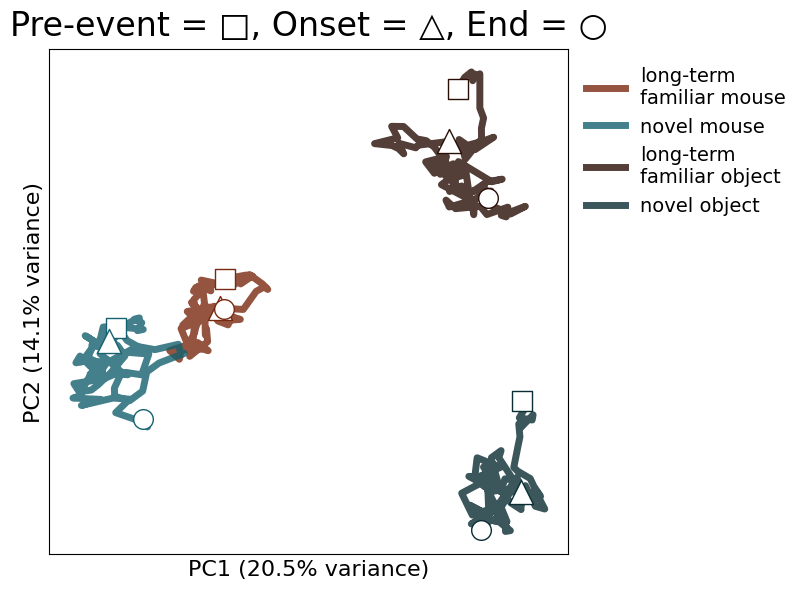

PCA Result with:
Events: familiar mouse, novel mouse, familiar object, novel object
Timebins per event: 80.0
Total neurons: 128
Number of recordings: 11
Number of Pcs needed to explain 90% of variance 40


In [28]:
plot_pca_results_2d(results, title = "Pre-event = □, Onset = △, End = ○", colors =['#792910','#15616F','#290e06','#0a2d33'], legend_spot = (1,1), custom_legend_labels = ['long-term\nfamiliar mouse',
'novel mouse', 'long-term\nfamiliar object', 'novel object']  )
print(results)

C:\Users\megha\AppData\Local\Temp\ipykernel_4964\1599970044.py:83: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


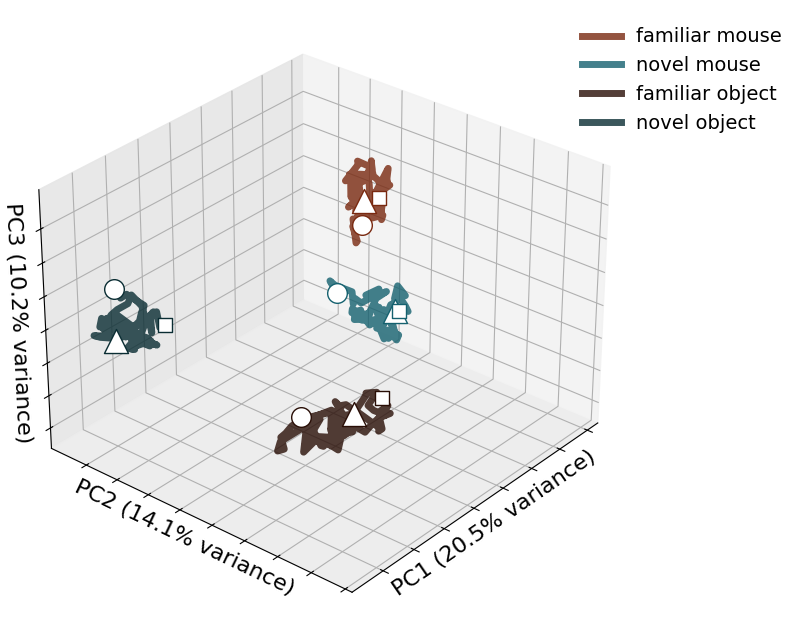

In [29]:
plot_pca_results_3d(results, title = '', colors =['#792910','#15616F','#290e06','#0a2d33'], azim = 40, elev = 30)

Excluding 31_object_merged.rec with 1 neurons


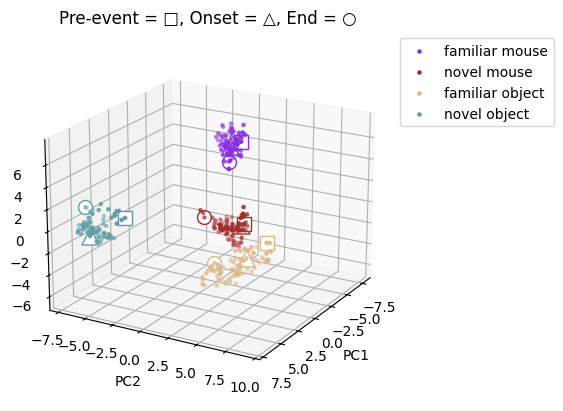

                                            Recording  Number of Neurons  \
0   20250618_123431_object_control_subj_1-3_merged...                 16   
1                                41_object_merged.rec                 16   
2   20250618_133349_object_control_subj_4-2_merged...                 16   
3   20250618_133349_object_control_subj_4-1_merged...                 14   
4   20250618_113931_object_control_subj_1-2_merged...                 14   
5   20250618_143034_object-control-subj_4-3_merged...                 12   
6   20250618_143034_object-control-subj_4-4_merged...                 11   
7                                22_object_merged.rec                  9   
8   20250618_113931_object_control_subj_6-1_merged...                  8   
9                                32_object_merged.rec                  8   
10                               44_object_merged.rec                  4   

    Number of familiar mouse events  Number of novel mouse events  \
0                 

In [30]:
population_analysis.avg_trajectories_pca(object_spikes, 3, pre_window = 1,
                                      events = ['familiar mouse', 'novel mouse', 'familiar object', 'novel object'],
                                      min_neurons = 4, d = 3)

Excluding 31_object_merged.rec with 1 neurons
Excluding 44_object_merged.rec with 4 neurons


C:\Users\megha\AppData\Local\Temp\ipykernel_4964\3387019861.py:45: MatplotlibDeprecationWarning: hatch must consist of a string of "*+-./OX\ox|" or None, but found the following invalid values "//". Passing invalid values is deprecated since 3.4 and will become an error in 3.9.
  legend_handles = [Patch(facecolor=color, label=label, hatch = hatches) for label, color in color_id_dict.items()]


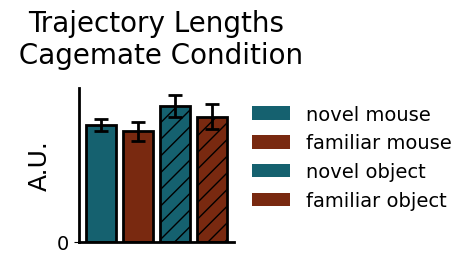

,Comparison,t_statistic,p_value,p_adjusted,significant
0,mouse,0.755334,0.469354,0.778287,False
1,fam,-1.875987,0.093403,0.373610,False
2,novel,-1.467170,0.176384,0.529152,False
3,object,0.904812,0.389143,0.778287,False


In [57]:
from scipy.spatial.distance import euclidean
from matplotlib.patches import Patch
from statsmodels.stats.multitest import multipletests
import matplotlib.ticker as ticker

events = ['familiar mouse', 'novel mouse', 'familiar object', 'novel object']
traj_lengths = population_analysis.avg_traj_len(object_spikes, 3, 2, post_window=0, min_neurons = 5, events = events, percent_var = 90)
trajectory_lengths = np.array(traj_lengths)


means = np.mean(trajectory_lengths, axis = 0)
sems = sem(trajectory_lengths, axis = 0)

t_nov_fam, p_nov_fam = stats.ttest_rel(trajectory_lengths[:,0], trajectory_lengths[:,1]) #fam mouse vs novel mouse
t_nov_cage, p_nov_cage = stats.ttest_rel(trajectory_lengths[:,0], trajectory_lengths[:,2]) #fam v fam
t_fam_cage, p_fam_cage = stats.ttest_rel(trajectory_lengths[:,1], trajectory_lengths[:,3]) #novel v novel
t_object, p_object = stats.ttest_rel(trajectory_lengths[:,2], trajectory_lengths[:,3]) #object v object
p_values = [p_nov_fam, p_nov_cage, p_fam_cage, p_object]
reject, p_adjusted, _, _ = multipletests(p_values, method='holm')
stats_df = pd.DataFrame({
   'Comparison': ['mouse', 'fam', 'novel', 'object'],
   't_statistic': [t_nov_fam, t_nov_cage, t_fam_cage, t_object],
   'p_value': p_values,
   'p_adjusted': p_adjusted,
   'significant': reject
})

#Adjust p-values using Holm-Bonferroni
p_values = [p_nov_fam, p_nov_cage, p_fam_cage]
reject, p_adjusted, _, _ = multipletests(p_values, method='holm')
color_id_dict = {'novel mouse': hex_2_rgb('#15616F'), 
                'familiar mouse': hex_2_rgb('#792910'),
                  'novel object': hex_2_rgb('#15616F'),
                  'familiar object': hex_2_rgb('#792910')}
hatches = ['','','//','//']
x = [0.5,1,1.5,2]
plt.figure(figsize= (2,2))           
plt.bar(x, means, yerr = sems,
            color = color_id_dict.values(), hatch = hatches,
            edgecolor = ['black', 'black', 'black', 'black'],
            capsize = 5, linewidth = 2,
            error_kw={'elinewidth': 2, 'capthick': 2}, 
            width = .4)
plt.xticks([],rotation=45)
legend_handles = [Patch(facecolor=color, label=label, hatch = hatches) for label, color in color_id_dict.items()]
plt.legend(handles=legend_handles,
           bbox_to_anchor=(1,1),
           frameon= False, fontsize = 14)
plt.ylabel('A.U.', fontsize = 18)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(50))
#plt.ylim(0,100)

plt.gca().spines['bottom'].set_linewidth(2)  # X-axis
plt.gca().spines['left'].set_linewidth(2) 
plt.title('Trajectory Lengths\n Cagemate Condition', fontsize = 20, y = 1.1)
plt.show()

stats_df


Paired t-test on participation ratio:
  n (matched subjects)   : 52
  mean PR_A              : 8.545 ± 0.052
  mean PR_B              : 7.833 ± 0.031
  mean difference (A-B)  : 0.712
  t = 11.828,  p = 0.0000  ***


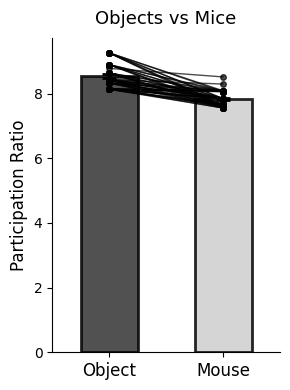

In [44]:
def paired_pr_test(df_a, df_b):
    from scipy.stats import ttest_rel

    a = df_a[['participation_ratio']].copy()
    b = df_b[['participation_ratio']].copy()

    # extract subject ID from index (everything before first underscore)
    a['subject'] = a.index.str.split('_').str[0]
    b['subject'] = b.index.str.split('_').str[0]

    merged = pd.merge(
        a.reset_index(), b.reset_index(),
        on='subject', how='inner',
        suffixes=('_A', '_B')
    )

    dropped_a = set(a['subject']) - set(merged['subject'])
    dropped_b = set(b['subject']) - set(merged['subject'])
    if dropped_a:
        print(f"Warning: subjects in A with no match: {dropped_a}")
    if dropped_b:
        print(f"Warning: subjects in B with no match: {dropped_b}")

    merged['difference'] = merged['participation_ratio_A'] - merged['participation_ratio_B']
    t, p = ttest_rel(merged['participation_ratio_A'], merged['participation_ratio_B'])

    def stars(p):
        if p < 0.001: return "***"
        if p < 0.01:  return "**"
        if p < 0.05:  return "*"
        return "n.s."

    print(f"\nPaired t-test on participation ratio:")
    print(f"  n (matched subjects)   : {len(merged)}")
    print(f"  mean PR_A              : {merged['participation_ratio_A'].mean():.3f} ± {merged['participation_ratio_A'].sem():.3f}")
    print(f"  mean PR_B              : {merged['participation_ratio_B'].mean():.3f} ± {merged['participation_ratio_B'].sem():.3f}")
    print(f"  mean difference (A-B)  : {merged['difference'].mean():.3f}")
    print(f"  t = {t:.3f},  p = {p:.4f}  {stars(p)}")

    return merged, t, p


def plot_pr_comparison(df_a, df_b, tick_labels, colors,
                       ylabel='Participation Ratio', title='Dimensionality comparison'):

    a = df_a[['participation_ratio']].copy()
    b = df_b[['participation_ratio']].copy()
    a['subject'] = a.index.str.split('_').str[0]
    b['subject'] = b.index.str.split('_').str[0]

    merged = pd.merge(
        a.reset_index(), b.reset_index(),
        on='subject', how='inner',
        suffixes=('_A', '_B')
    )

    means = [merged['participation_ratio_A'].mean(), merged['participation_ratio_B'].mean()]
    sems  = [merged['participation_ratio_A'].sem(),  merged['participation_ratio_B'].sem()]

    fig, ax = plt.subplots(figsize=(3, 4))

    ax.bar([0, 1], means, yerr=sems, color=colors, width=0.5,
           capsize=5, error_kw={'elinewidth': 2, 'capthick': 2},
           alpha=0.85, zorder=2, linewidth = 2, edgecolor = 'black')

    for _, row in merged.iterrows():
        ax.plot([0, 1],
                [row['participation_ratio_A'], row['participation_ratio_B']],
                color='black', linewidth=1, alpha=0.7,
                marker='o', markersize=4, zorder=3)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(tick_labels, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=13, pad=10)
    ax.set_xlim(-0.5, 1.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()
    
pr_object = population_analysis.participation_ratio(object_spikes, 3, 3, events = ['familiar object', 'novel object'],min_neurons=5, LOO = True)
pr_mouse = population_analysis.participation_ratio(object_spikes, 3, 3, events = ['familiar mouse', 'novel mouse'],min_neurons=5, LOO = True)
merged_pr, t_stat, p_value = paired_pr_test(pr_object, pr_mouse)
plot_pr_comparison(pr_object, pr_mouse, tick_labels=['Object', 'Mouse'], colors=["#323232", "#CECECE"], title='Objects vs Mice')


Paired t-test on participation ratio:
  n (matched subjects)   : 52
  mean PR_A              : 11.434 ± 0.071
  mean PR_B              : 7.475 ± 0.047
  mean difference (A-B)  : 3.959
  t = 48.769,  p = 0.0000  ***


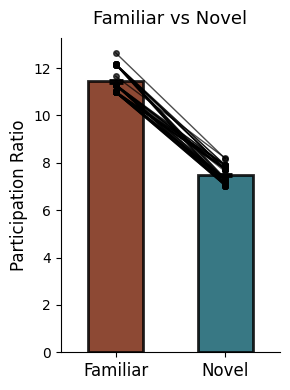

In [33]:
pr_fam = population_analysis.participation_ratio(object_spikes, 3, 3, events = ['familiar object', 'familiar mouse'],min_neurons=5, LOO = True)
pr_novel = population_analysis.participation_ratio(object_spikes, 3, 3, events = ['novel object', 'novel mouse'],min_neurons=5, LOO = True)
merged_pr, t_stat, p_value = paired_pr_test(pr_fam, pr_novel)
plot_pr_comparison(pr_fam, pr_novel, tick_labels=['Familiar', 'Novel'], colors=['#792910', '#15616F'], title='Familiar vs Novel')

In [52]:
from itertools import combinations
def test_rsa_across_events_across_subjects(df, correction='fdr_bh'):
    """
    Paired t-test for all pairs of events, using subject pair as the pairing unit.
    Input df should come from rsa(..., across_subjects=True).

    Args:
        df: DataFrame with columns ['event', 'subject_1', 'subject_2', 'rsa']
        correction: str, multiple comparison correction method (e.g. 'fdr_bh', 'holm')

    Returns:
        stats_df: DataFrame with columns:
            ['event_1', 'event_2', 'mean_1', 'mean_2', 'sem_1', 'sem_2',
            't_statistic', 'p_value', 'p_adjusted', 'significant']
    """
    df = df.copy()
    df['pair_id'] = df.apply(lambda r: tuple(sorted([r['subject_1'], r['subject_2']])), axis=1)
    events = df['event'].unique()

    rows = []
    for e1, e2 in combinations(events, 2):
        d1 = df[df['event'] == e1].set_index('pair_id')['rsa']
        d2 = df[df['event'] == e2].set_index('pair_id')['rsa']

        shared = d1.index.intersection(d2.index)
        v1 = d1.loc[shared].values
        v2 = d2.loc[shared].values

        t, p = stats.ttest_rel(v1, v2)
        rows.append({
            'event_1': e1,
            'event_2': e2,
            'mean_1': np.mean(v1),
            'mean_2': np.mean(v2),
            'sem_1': stats.sem(v1),
            'sem_2': stats.sem(v2),
            't_statistic': t,
            'p_value': p,
        })

    stats_df = pd.DataFrame(rows)
    reject, p_adj, _, _ = multipletests(stats_df['p_value'], method=correction)
    stats_df['p_adjusted'] = p_adj
    stats_df['significant'] = reject
    return stats_df


All set to analyze
Skipping 31_object_merged.rec: 1 neurons < min_neurons=5
Skipping 44_object_merged.rec: 4 neurons < min_neurons=5
Skipping 31_object_merged.rec: 1 neurons < min_neurons=5
Skipping 44_object_merged.rec: 4 neurons < min_neurons=5
Skipping 31_object_merged.rec: 1 neurons < min_neurons=5
Skipping 44_object_merged.rec: 4 neurons < min_neurons=5
Skipping 31_object_merged.rec: 1 neurons < min_neurons=5
Skipping 44_object_merged.rec: 4 neurons < min_neurons=5


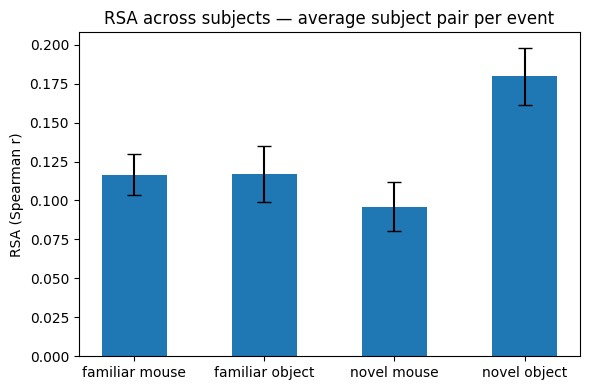

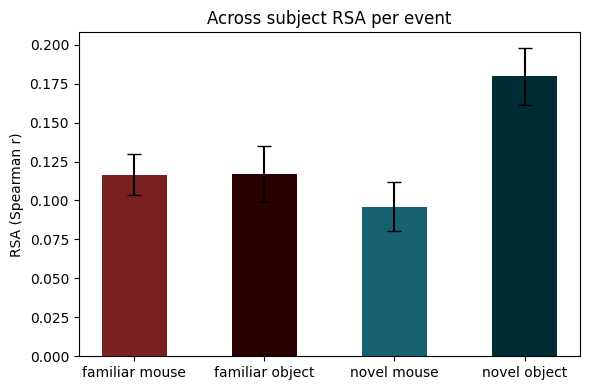

           event_1          event_2    mean_1    mean_2     sem_1     sem_2  \
0   familiar mouse      novel mouse  0.116600  0.096127  0.013195  0.015701   
1   familiar mouse  familiar object  0.116600  0.116978  0.013195  0.018038   
2   familiar mouse     novel object  0.116600  0.179595  0.013195  0.018437   
3      novel mouse  familiar object  0.096127  0.116978  0.015701  0.018038   
4      novel mouse     novel object  0.096127  0.179595  0.015701  0.018437   
5  familiar object     novel object  0.116978  0.179595  0.018038  0.018437   

   t_statistic   p_value  p_adjusted  significant  
0     0.854998  0.397184    0.476621        False  
1    -0.017362  0.986226    0.986226        False  
2    -2.777852  0.008013    0.024039         True  
3    -0.897668  0.374248    0.476621        False  
4    -3.615144  0.000768    0.004608         True  
5    -2.399966  0.020695    0.041390         True  
Skipping 31_object_merged.rec: 1 neurons < min_neurons=5
Skipping 44_object_merged

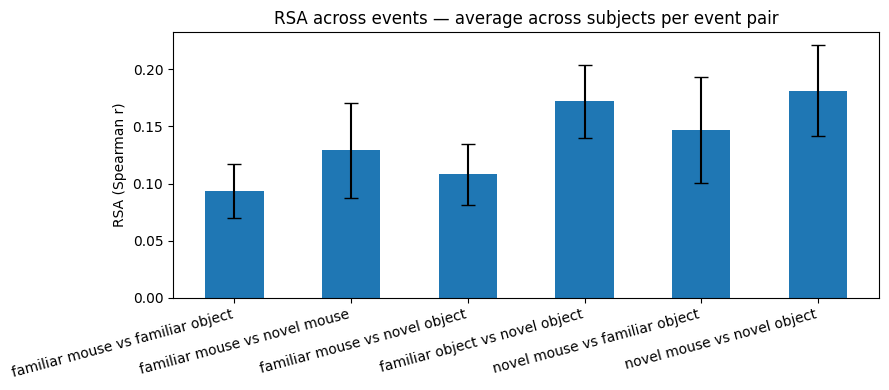

Skipping 31_object_merged.rec: 1 neurons < min_neurons=5
Skipping 44_object_merged.rec: 4 neurons < min_neurons=5


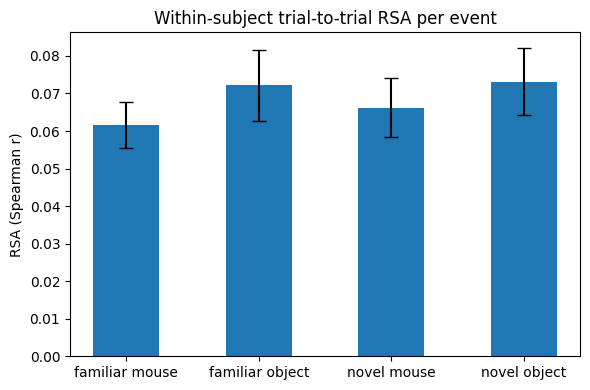

In [54]:
object_spikes.analyze(100, ignore_freq = 0.5, smoothing_window = 250)

rsa_across_subjects = population_analysis.rsa(object_spikes, events = ['familiar mouse', 'novel mouse', 'familiar object', 'novel object'],
                        across_subjects=True, event_length = 3, pre_window = 1, plot = True, min_neurons = 5)

event_rsa = rsa_across_subjects.groupby("event")["rsa"].apply(list)
labels = list(event_rsa.index)
means = [np.mean(event_rsa[e]) for e in labels]
errors = [sem(event_rsa[e]) for e in labels]
x = np.arange(len(labels))
plt.figure(figsize=(max(4, len(labels) * 1.5), 4))
plt.bar(x, means, yerr=errors, capsize=5, width=0.5, color=[ '#792120',"#290100",'#15616F',"#002D35"])
plt.xticks(x, labels)
plt.ylabel("RSA (Spearman r)")
plt.title("Across subject RSA per event")
plt.tight_layout()
plt.show()
print(test_rsa_across_events_across_subjects(rsa_across_subjects))
rsa_across_events = population_analysis.rsa(object_spikes, events = ['familiar mouse', 'novel mouse', 'familiar object', 'novel object'],
                        across_events=True, event_length = 3, pre_window = 1, plot = True, min_neurons = 5,)
                         # n_perm = 1000, correction = 'fdr_bh')

rsa_within_subjects = population_analysis.rsa(object_spikes, events = ['familiar mouse', 'novel mouse', 'familiar object', 'novel object'],
                        event_length = 3, pre_window = 1, plot = True, min_neurons = 5,) 
                        #n_perm = 1000, correction = 'fdr_bh')



In [35]:
eli_spikes = collection.SpikeCollection.load_collection(r"C:\Users\megha\UF Dropbox\Meghan Cum\Padilla-Coreano Lab\2024\Cum_SocialMemEphys_pilot2\Object_Control (phase 7)\object_collection")

eli_spikes.recordings = [
    r for r in eli_spikes.recordings
    if float(r.subject) >= 5
]

meg_spikes = collection.SpikeCollection.load_collection(r"C:\Users\megha\UF Dropbox\Meghan Cum\Padilla-Coreano Lab\2024\Cum_SocialMemEphys_pilot2\Object_Control (phase 7)\object_collection")

meg_spikes.recordings = [
    r for r in meg_spikes.recordings
    if float(r.subject) < 5
]
meg_spikes.analyze(smoothing_window = 250, timebin = 100, ignore_freq = 0.5)
eli_spikes.analyze(smoothing_window = 250, timebin = 100, ignore_freq = 0.5)

All set to analyze
All set to analyze


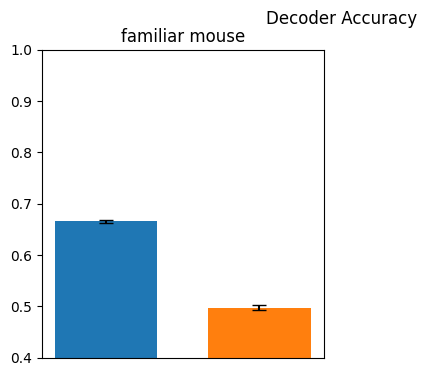

In [36]:
num_folds = 5
mouse_v_mouse = decoders.trial_decoder(eli_spikes, 
                                                events = ['familiar mouse', 'novel mouse'], 
                                                event_length = 4,
                                                pre_window = 3,
                                                min_neurons = 5,
                                                num_fold = num_folds,
                                                percent_var = 90,
                                                classifier_type = 'linear')
mouse_v_mouse.plot_average()

Excluding 31_object_merged.rec with 1 neurons
Excluding 44_object_merged.rec with 4 neurons
Excluding 31_object_merged.rec with 1 neurons
Excluding 44_object_merged.rec with 4 neurons
Excluding 31_object_merged.rec with 1 neurons
Excluding 44_object_merged.rec with 4 neurons
Excluding 31_object_merged.rec with 1 neurons
Excluding 44_object_merged.rec with 4 neurons
Excluding 31_object_merged.rec with 1 neurons
Excluding 44_object_merged.rec with 4 neurons
Excluding 31_object_merged.rec with 1 neurons
Excluding 44_object_merged.rec with 4 neurons


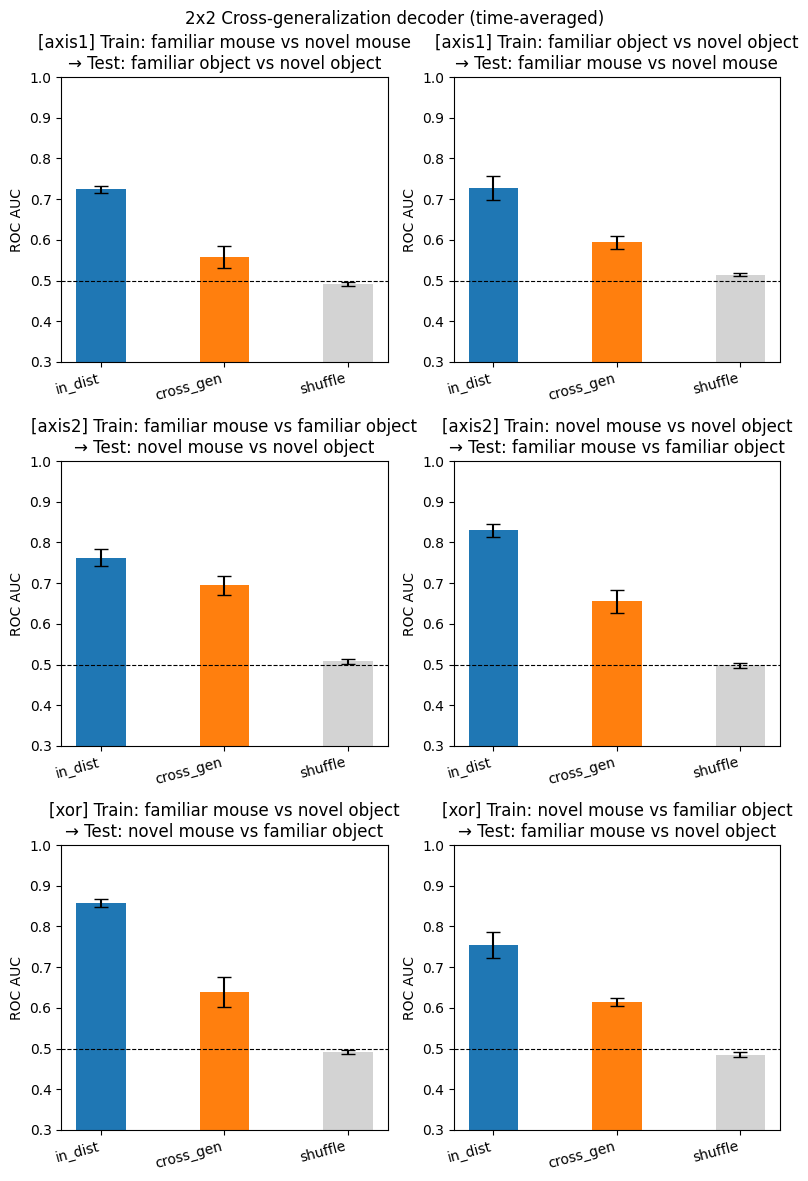

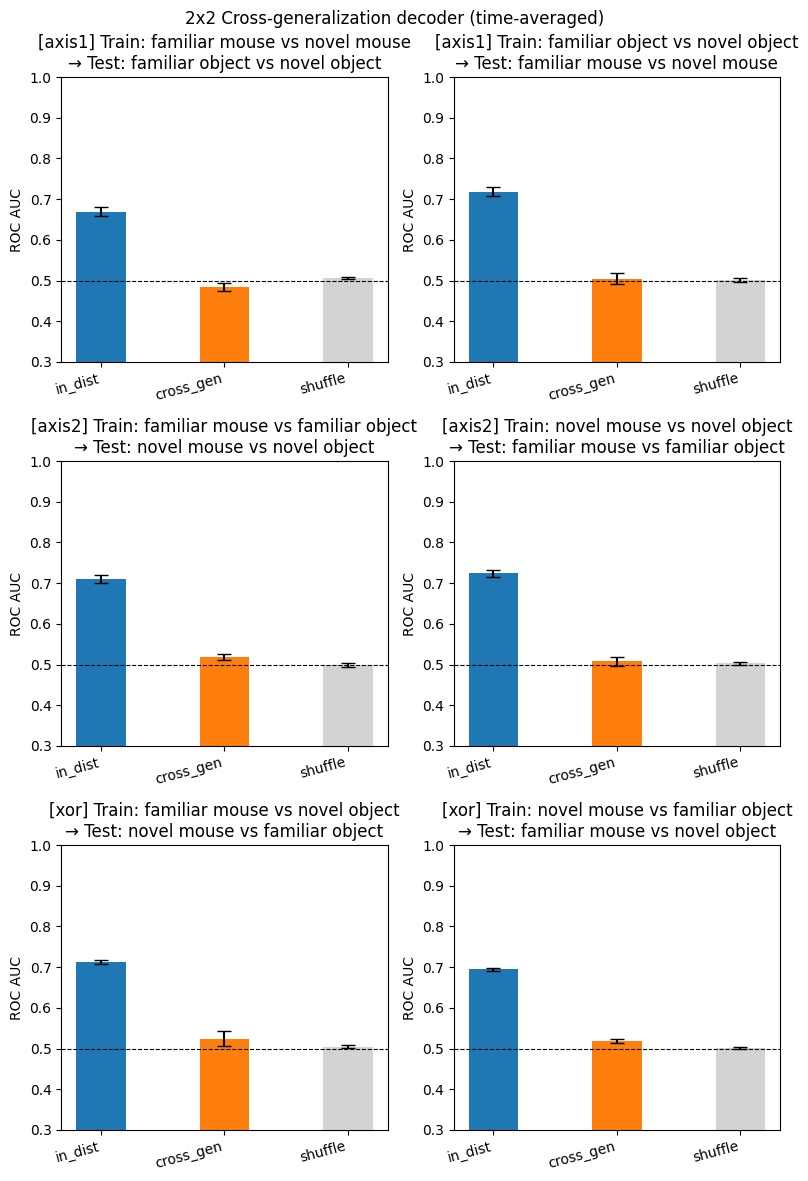

In [37]:
num_folds = 5
meg_ccgp_object = decoders.trial_decoder_cross_generalization_2x2(meg_spikes, 
                                                events = [['familiar mouse', 'novel mouse'], ['familiar object', 'novel object']], 
                                                event_length = 3,
                                                pre_window = 4,
                                                min_neurons = 5,
                                                num_fold = num_folds,
                                                classifier_type = 'linear')
meg_ccgp_object.plot_average()
num_folds = 5
eli_ccgp_object = decoders.trial_decoder_cross_generalization_2x2(eli_spikes, 
                                                events = [['familiar mouse', 'novel mouse'], ['familiar object', 'novel object']], 
                                                event_length = 3,
                                                pre_window = 4,
                                                min_neurons = 5,
                                                num_fold = num_folds,
                                                classifier_type = 'linear')
eli_ccgp_object.plot_average()

All set to analyze
Skipping 31_object_merged.rec: 1 neurons < min_neurons=5
Skipping 44_object_merged.rec: 4 neurons < min_neurons=5
Skipping 31_object_merged.rec: 1 neurons < min_neurons=5
Skipping 44_object_merged.rec: 4 neurons < min_neurons=5
Skipping 31_object_merged.rec: 1 neurons < min_neurons=5
Skipping 44_object_merged.rec: 4 neurons < min_neurons=5
Skipping 31_object_merged.rec: 1 neurons < min_neurons=5
Skipping 44_object_merged.rec: 4 neurons < min_neurons=5


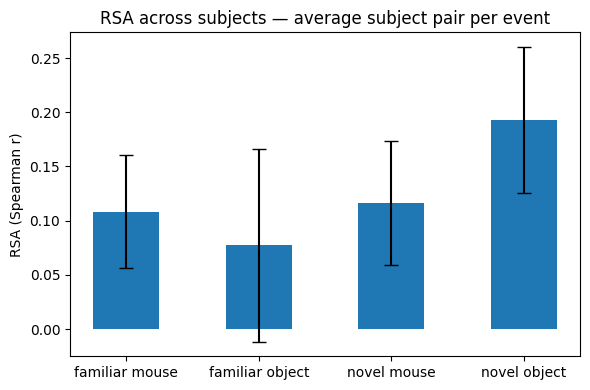

Skipping 31_object_merged.rec: 1 neurons < min_neurons=5
Skipping 44_object_merged.rec: 4 neurons < min_neurons=5


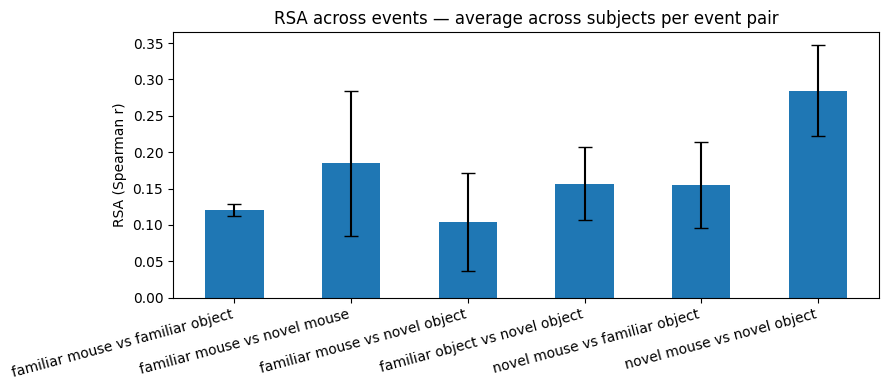

Skipping 31_object_merged.rec: 1 neurons < min_neurons=5
Skipping 44_object_merged.rec: 4 neurons < min_neurons=5


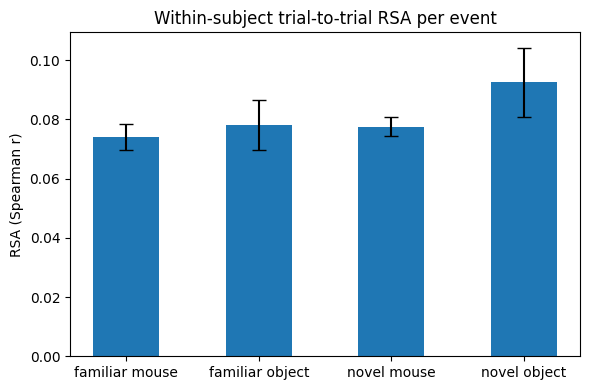

In [47]:
meg_spikes.analyze(100, ignore_freq = 0.5, smoothing_window = 250)

rsa_across_subjects = population_analysis.rsa(meg_spikes, events = ['familiar mouse', 'novel mouse', 'familiar object', 'novel object'],
                        across_subjects=True, event_length = 3, pre_window = 1, plot = True, min_neurons = 5)

rsa_across_events = population_analysis.rsa(meg_spikes, events = ['familiar mouse', 'novel mouse', 'familiar object', 'novel object'],
                        across_events=True, event_length = 3, pre_window = 1, plot = True, min_neurons = 5,)
                         # n_perm = 1000, correction = 'fdr_bh')

rsa_within_subjects = population_analysis.rsa(meg_spikes, events = ['familiar mouse', 'novel mouse', 'familiar object', 'novel object'],
                        event_length = 3, pre_window = 1, plot = True, min_neurons = 5,) 
                        #n_perm = 1000, correction = 'fdr_bh')



Excluding 31_object_merged.rec with 1 neurons
Excluding 44_object_merged.rec with 4 neurons
Excluding 31_object_merged.rec with 1 neurons
Excluding 44_object_merged.rec with 4 neurons
Excluding 31_object_merged.rec with 1 neurons
Excluding 44_object_merged.rec with 4 neurons
Excluding 31_object_merged.rec with 1 neurons
Excluding 44_object_merged.rec with 4 neurons
Excluding 31_object_merged.rec with 1 neurons
Excluding 44_object_merged.rec with 4 neurons
Excluding 31_object_merged.rec with 1 neurons
Excluding 44_object_merged.rec with 4 neurons


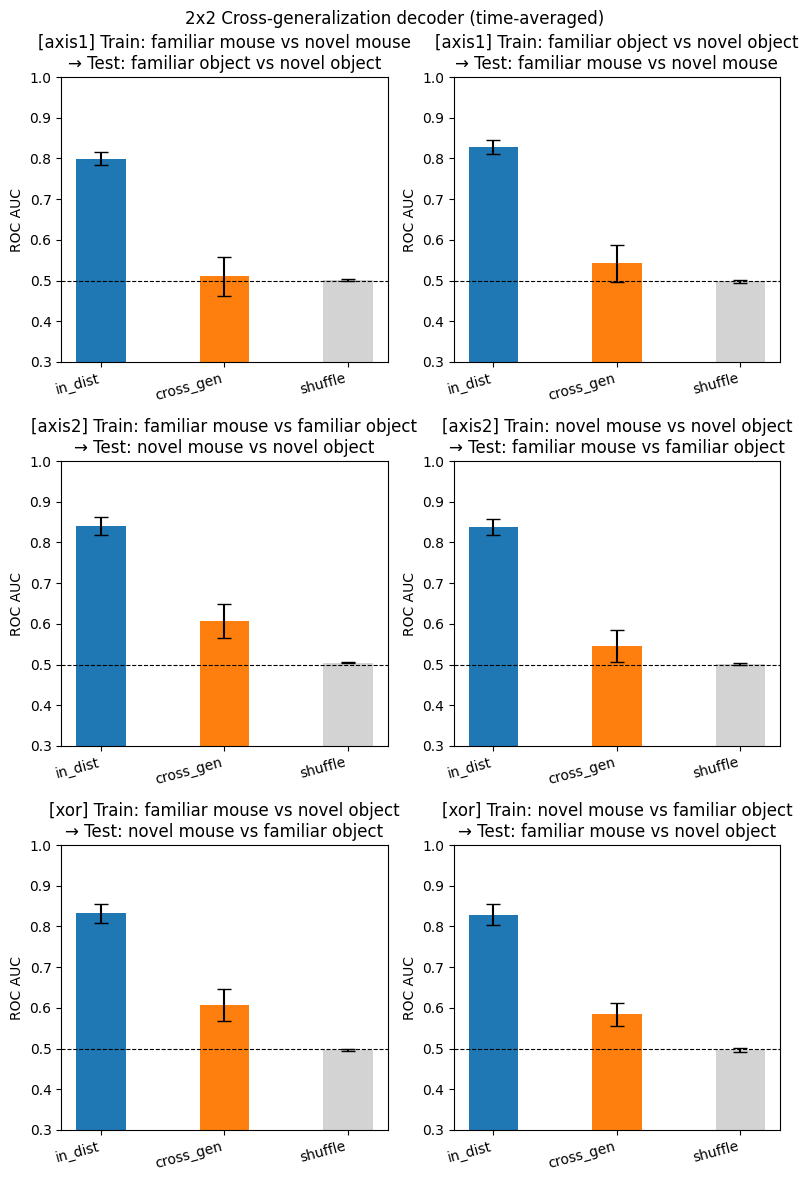

In [48]:
num_folds = 5
ccgp_object = decoders.trial_decoder_cross_generalization_2x2(object_spikes, 
                                                events = [['familiar mouse', 'novel mouse'], ['familiar object', 'novel object']], 
                                                event_length = 3,
                                                pre_window = 4,
                                                min_neurons = 5,
                                                num_fold = num_folds,
                                                classifier_type = 'linear',
                                                LOO = True)
ccgp_object.plot_average()

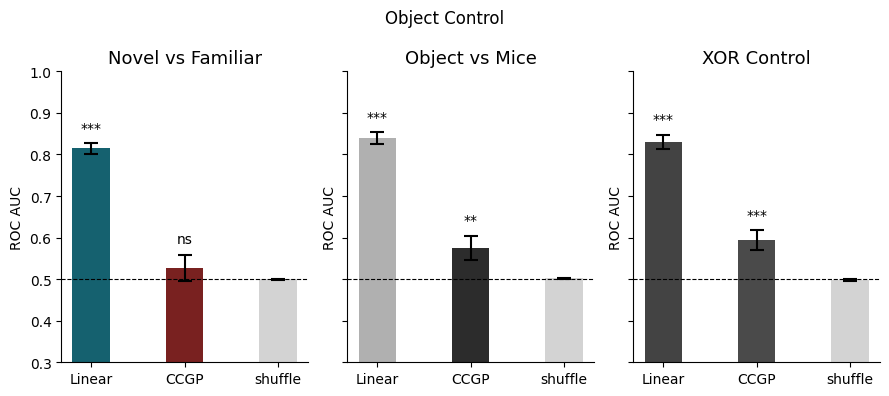

In [49]:
from scipy.stats import sem, ttest_ind                                                                                                                                                                                                                                                                                  
                                                                                                                                                                                                                                                                                                                          
def plot_average(ccgp_object, colors, start=0, stop=None, collapse=False,                                                                                                                                                                                                                                               
                titles=None, xtick_labels=None, suptitle=None):                                                                                                                                                                                                                                                                       
                                                                                                                                                                                                                                                                                                                    
    def sig_stars(p):
        if p < 0.001: return "***"
        elif p < 0.01:  return "**"
        elif p < 0.05:  return "*"
        else:           return "ns"

    def annotate_bars(ax, x_pos, means, errors, pvals):
        for xi, mean, err, p in zip(x_pos, means, errors, pvals):
            if p is not None:
                ax.text(xi, mean + err + 0.02, sig_stars(p),
                        ha="center", va="bottom", fontsize=10)

    def fold_array(nmr, start, stop, ccgp_object):
        T = nmr.roc_auc.shape[0]
        x = np.linspace(-ccgp_object.pre_window,
                        ccgp_object.event_length + ccgp_object.post_window, T)
        start_idx = np.searchsorted(x, start)
        stop_idx  = T if stop is None else np.searchsorted(x, stop)
        return np.nanmean(nmr.roc_auc[start_idx:stop_idx], axis=0)

    def mean_err(arr):
        clean = arr[~np.isnan(arr)]
        return np.nanmean(clean), sem(clean, nan_policy="omit")

    def vs_shuffle_p(arr, shuf_arr):
        a = arr[~np.isnan(arr)]
        b = shuf_arr[~np.isnan(shuf_arr)]
        _, p = ttest_ind(a, b, alternative="greater")
        return p

    train_keys  = list(ccgp_object.roc_auc_scores.keys())
    axis_groups = [train_keys[0:2], train_keys[2:4]]
    if len(train_keys) >= 6:
        axis_groups.append(train_keys[4:6])
    n_groups = len(axis_groups)

    bar_width = 0.4

    # ------------------------------------------------------------------ #
    #  COLLAPSE MODE                                                       #
    # ------------------------------------------------------------------ #
    if collapse:
        fig, axes = plt.subplots(1, n_groups, figsize=(3 * n_groups, 4), sharey=True)
        if n_groups == 1:
            axes = [axes]

        for ax_idx, (ax, group_keys, axis_colors) in enumerate(
                zip(axes, axis_groups, colors)):

            in_dist_folds   = []
            cross_gen_folds = []
            shuffle_folds   = []

            for train_key in group_keys:
                results = ccgp_object.roc_auc_scores[train_key]
                for result_type, nmr in results.items():
                    arr = fold_array(nmr, start, stop, ccgp_object)
                    if result_type == "in_dist":
                        in_dist_folds.append(arr)
                    elif result_type == "cross_gen":
                        cross_gen_folds.append(arr)
                    elif result_type == "shuffle":
                        shuffle_folds.append(arr)

            def pool(fold_list):
                return np.concatenate(fold_list) if fold_list else np.array([np.nan])

            in_arr    = pool(in_dist_folds)
            cross_arr = pool(cross_gen_folds)
            shuf_arr  = pool(shuffle_folds)

            in_mean,    in_err    = mean_err(in_arr)
            cross_mean, cross_err = mean_err(cross_arr)
            shuf_mean,  shuf_err  = mean_err(shuf_arr)

            means      = [in_mean,        cross_mean,    shuf_mean]
            errors     = [in_err,         cross_err,     shuf_err]
            pvals      = [vs_shuffle_p(in_arr, shuf_arr),
                        vs_shuffle_p(cross_arr, shuf_arr),
                        None]  # shuffle bar needs no annotation
            bar_colors = [axis_colors[0], axis_colors[1], "lightgray"]

            xlabels = xtick_labels[ax_idx] if xtick_labels is not None else ["in-dist", "cross-gen", "shuffle"]

            x_pos = np.arange(3)
            ax.bar(x_pos, means, bar_width, yerr=errors, capsize=5,
                    color=bar_colors,
                    error_kw={"elinewidth": 1.5, "capthick": 1.5})
            annotate_bars(ax, x_pos, means, errors, pvals)
            ax.set_xticks(x_pos)
            ax.set_xticklabels(xlabels, rotation=0, ha="center")
            ax.axhline(0.5, color="k", linestyle="--", linewidth=0.8)
            ax.set_ylim(0.3, 1.0)
            ax.set_ylabel("ROC AUC")
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

            title = titles[ax_idx] if titles is not None else ("XOR" if ax_idx == 2 else f"Axis {ax_idx + 1}")
            ax.set_title(title, fontsize=13)

    # ------------------------------------------------------------------ #
    #  FULL MODE                                                           #
    # ------------------------------------------------------------------ #
    else:
        fig, axes_grid = plt.subplots(n_groups, 2, figsize=(10, 4 * n_groups), sharey=True)
        if n_groups == 1:
            axes_grid = axes_grid[np.newaxis, :]

        for axis_idx, (group_keys, axis_colors) in enumerate(
                zip(axis_groups, colors)):

            for subplot_idx, train_key in enumerate(group_keys):
                ax = axes_grid[axis_idx, subplot_idx]
                results = ccgp_object.roc_auc_scores[train_key]
                result_items = list(results.items())

                # get shuffle array first so we can test against it
                shuf_arr = next(
                    (fold_array(nmr, start, stop, ccgp_object)
                    for rt, nmr in result_items if rt == "shuffle"),
                    None
                )

                means, errors, pvals, bar_colors = [], [], [], []

                for j, (result_type, nmr) in enumerate(result_items):
                    arr = fold_array(nmr, start, stop, ccgp_object)
                    mean, err = mean_err(arr)
                    means.append(mean)
                    errors.append(err)

                    if result_type == "shuffle" or shuf_arr is None:
                        pvals.append(None)
                        bar_colors.append("lightgray")
                    else:
                        pvals.append(vs_shuffle_p(arr, shuf_arr))
                        bar_colors.append(axis_colors[0] if j == 0 else axis_colors[1])

                if xtick_labels is not None:
                    xlabels = list(xtick_labels[axis_idx][subplot_idx])
                    while len(xlabels) < len(result_items):
                        xlabels.append("shuffle")
                else:
                    xlabels = [rt for rt, _ in result_items]

                x_pos = np.arange(len(result_items))
                ax.bar(x_pos, means, bar_width, yerr=errors, capsize=5,
                        color=bar_colors,
                        error_kw={"elinewidth": 1.5, "capthick": 1.5})
                annotate_bars(ax, x_pos, means, errors, pvals)
                ax.set_xticks(x_pos)
                ax.set_xticklabels(xlabels, rotation=15, ha="center")
                ax.axhline(0.5, color="k", linestyle="--", linewidth=0.8)
                ax.set_ylim(0.3, 1.0)
                ax.set_ylabel("ROC AUC")
                ax.spines["top"].set_visible(False)
                ax.spines["right"].set_visible(False)

                if titles is not None:
                    title = titles[axis_idx][subplot_idx]
                else:
                    title = "XOR" if axis_idx == 2 else f"Axis {axis_idx+1}, subplot {subplot_idx+1}"
                ax.set_title(title, fontsize=12)
    if suptitle is None:
        suptitle = "2x2 Cross-generalization decoder (time-averaged)"
    plt.suptitle(suptitle)
    plt.tight_layout()
    plt.show()

plot_average(ccgp_object, 
             colors = [[hex_2_rgb('#15616F'),hex_2_rgb("#792120")],
                       [hex_2_rgb("#b0b0b0"),hex_2_rgb("#2c2c2c")],
                       [hex_2_rgb("#434343"),hex_2_rgb("#4a4a4a")]],
                       start = 0 , stop =3, collapse = True,
             titles = ['Novel vs Familiar', 
                       'Object vs Mice', 
                       'XOR Control'],
             xtick_labels = [['Linear','CCGP', 'shuffle'],
                             ['Linear','CCGP', 'shuffle'],
                             ['Linear','CCGP', 'shuffle']],
             suptitle = 'Object Control')


All set to analyze
Excluding 31_object_merged.rec with 1 neurons
Excluding 44_object_merged.rec with 4 neurons
Excluding 31_object_merged.rec with 1 neurons
Excluding 44_object_merged.rec with 4 neurons
Excluding 31_object_merged.rec with 1 neurons
Excluding 44_object_merged.rec with 4 neurons
Excluding 31_object_merged.rec with 1 neurons
Excluding 44_object_merged.rec with 4 neurons
Excluding 31_object_merged.rec with 1 neurons
Excluding 44_object_merged.rec with 4 neurons
Excluding 31_object_merged.rec with 1 neurons
Excluding 44_object_merged.rec with 4 neurons


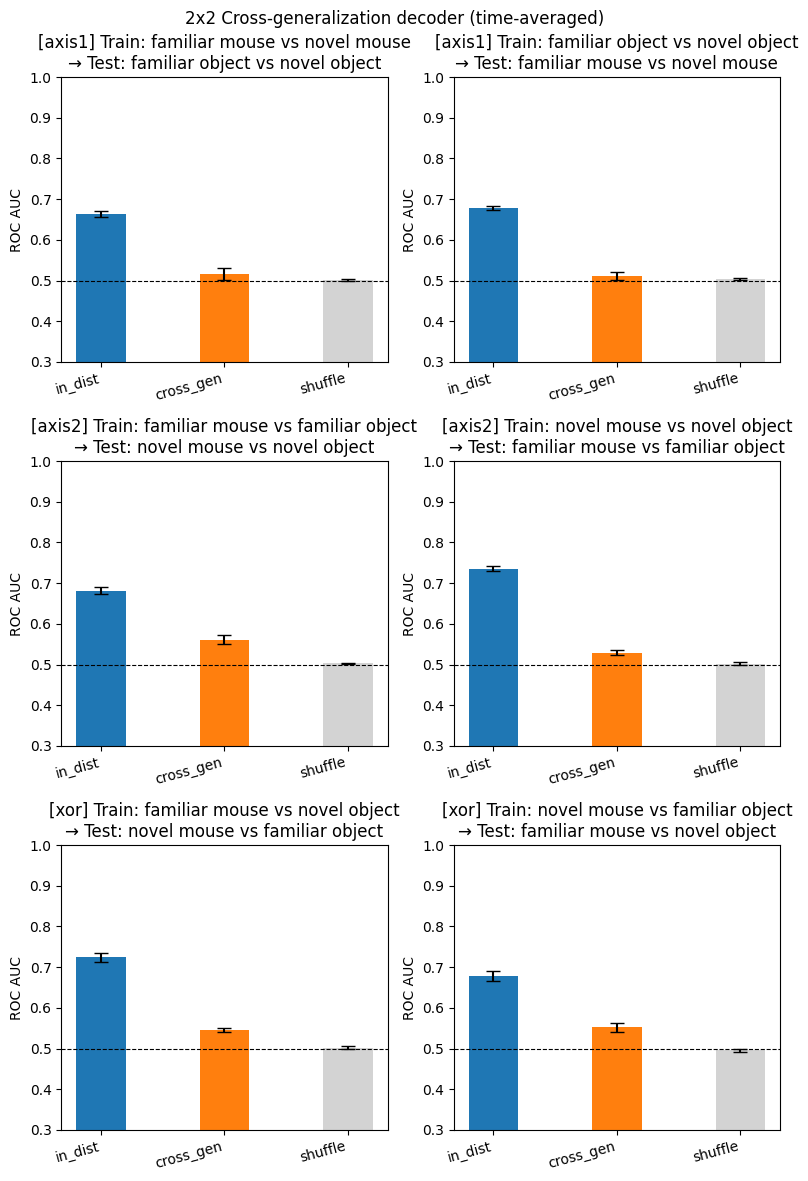

In [39]:
num_folds = 5
object_spikes.analyze(smoothing_window = 250, timebin = 100, ignore_freq = 0.5)
ccgp_object = decoders.trial_decoder_cross_generalization_2x2(object_spikes, 
                                                events = [['familiar mouse', 'novel mouse'], ['familiar object', 'novel object']], 
                                                event_length = 3,
                                                pre_window = 4,
                                                min_neurons = 5,
                                                num_fold = num_folds,
                                                percent_var = 99,
                                                classifier_type = 'linear')
ccgp_object.plot_average()

In [40]:
print(mouse_v_mouse)

Models ran with 5 folds
Variance threshold: 90%  |  PCs used: 41
Events: ['familiar mouse']
  familiar mouse: Model Results
Average AUC score: 0.6649875950380152
Average AUC score for shuffled data: 0.49983463385354143


All set to analyze
Excluding 31_object_merged.rec with 1 neurons
Excluding 44_object_merged.rec with 4 neurons


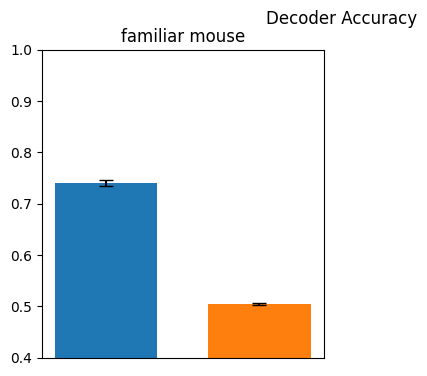

In [41]:
object_spikes.analyze(smoothing_window = 500, timebin = 100, ignore_freq = 0.5)
mouse_v_mouse = decoders.trial_decoder(object_spikes, 
                                                events = ['familiar mouse', 'novel mouse'], 
                                                event_length = 4,
                                                pre_window = 3,
                                                min_neurons = 5,
                                                num_fold = num_folds,
                                                percent_var = 99,
                                                classifier_type = 'linear')
mouse_v_mouse.plot_average()

Excluding 31_object_merged.rec with 1 neurons


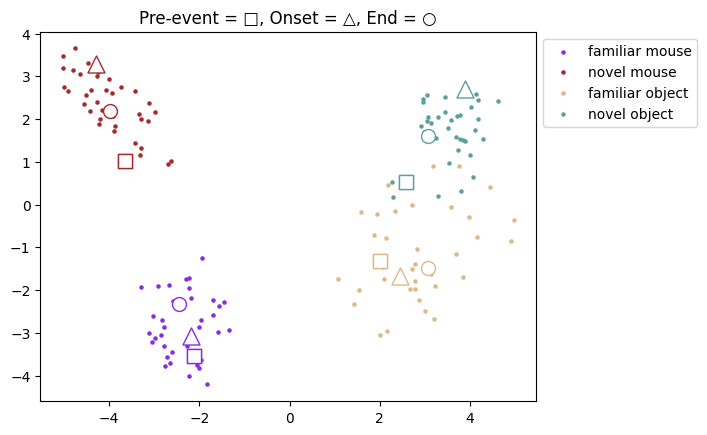

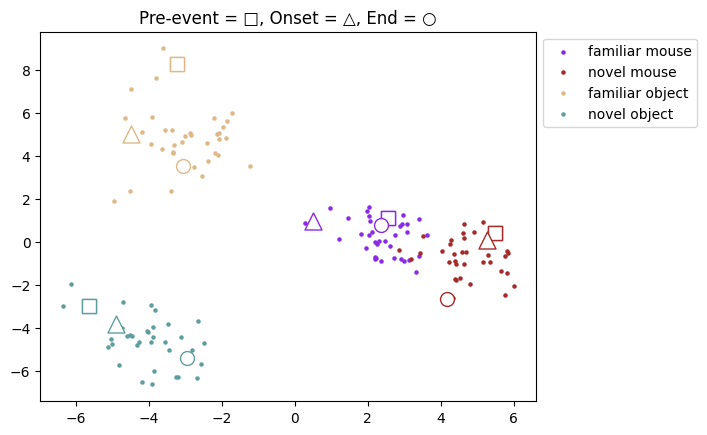

                                           Recording  Number of Neurons  \
0  20250618_123431_object_control_subj_1-3_merged...                 16   
1  20250618_133349_object_control_subj_4-2_merged...                 16   
2  20250618_113931_object_control_subj_1-2_merged...                 14   
3  20250618_133349_object_control_subj_4-1_merged...                 14   
4  20250618_143034_object-control-subj_4-3_merged...                 12   
5  20250618_143034_object-control-subj_4-4_merged...                 11   
6  20250618_113931_object_control_subj_6-1_merged...                  8   

   Number of familiar mouse events  Number of novel mouse events  \
0                               30                            29   
1                               22                            27   
2                               22                            22   
3                               27                            25   
4                               37                         

In [42]:
population_analysis.avg_trajectories_pca(meg_spikes, 3, pre_window = 1,
                                      events = ['familiar mouse', 'novel mouse', 'familiar object', 'novel object'],
                                      min_neurons = 4, d = 2)
population_analysis.avg_trajectories_pca(eli_spikes, 3, pre_window = 1,
                                      events = ['familiar mouse', 'novel mouse', 'familiar object', 'novel object'],
                                      min_neurons = 4, d = 2)
